In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(filepath_or_buffer = "../little_project/height-weight-25k.csv", 
            sep =',')

In [5]:
df.head()

,Index,Height-Inches,Weight-Pounds
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [6]:
import seaborn as sns

In [12]:
import numpy as np
import matplotlib.pyplot as plt

Диаграмма рассеяния. для визуализации набора данных воспользуемся библиотекой seaborn для Python

/home/tooks/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


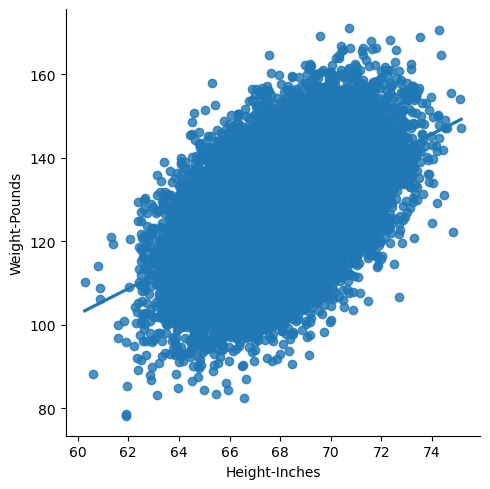

In [13]:
sns.lmplot(x="Height-Inches", y="Weight-Pounds", data=df)

Общие статистические показатели

In [15]:
df.describe()

,Index,Height-Inches,Weight-Pounds
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


Ядерное распределение плотности
Распределение из графика плотности демонстрирует зависимость двух переменных друг от друга

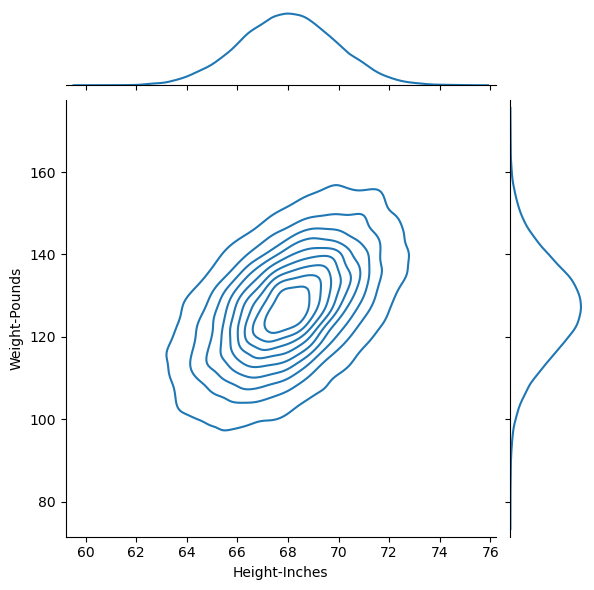

In [18]:
sns.jointplot(x="Height-Inches", y="Weight-Pounds", data=df, kind="kde")

Моделирование. При моделировании на основе машинного 
обучения алгоритм усваивает закономерности из данных. Общий смысл — пред
сказать будущие данные на основе предыдущих.
Модель регрессии sklearn
Сначала из данных выделяются признаки и целевые переменные, затем данные 
разбиваются на обучающий и контрольный наборы данных
контрольный набор данных отделяется для последующей проверки безошибоч
ности обученной модели.

In [19]:
from sklearn.model_selection import train_test_split

Выделение и изучение признаков и целевой переменной. Полезно явно извлечь 
целевую переменную и переменные признаков и привести их к единой форме. 
После этого желательно проверить форму и убедиться, что она подходит для 
машинного обучения с помощью sklearn.

In [20]:
y = df['Weight-Pounds'].values #Цель
y = y.reshape(-1, 1)
X = df['Height-Inches'].values #Признак(и)
X = X.reshape(-1, 1)

In [21]:
y.shape

(25000, 1)

Разбиение данных. Данные разбиваются в соотношении 80/20 %

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(20000, 1) (20000, 1)
(5000, 1) (5000, 1)


Подгонка модели. Производим подгонку модели с помощью алгоритма линей
ной регрессии, импортируемого из sklearn

In [23]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
model = lm.fit(X_train, y_train)
y_predicted = lm.predict(X_test)

Выводим показатель безошибочности модели линейной регрессии.
какую безошибочность демонстрирует обученная модель при предсказании новых данных. Для этого вычисляем RMSE (root mean squared 
error — среднеквадратическая ошибка) предсказанных и контрольных данных

In [24]:
from sklearn.metrics import mean_squared_error
from math import sqrt
# RMSE — среднеквадратическая ошибка
rms = sqrt(mean_squared_error(y_predicted, y_test))
rms

9.987787597720878

График соотношения предсказанного и истинного роста. построим 
график соотношения предсказанного и истинного роста, чтобы вы яснить, насколько хороши предсказания модели.

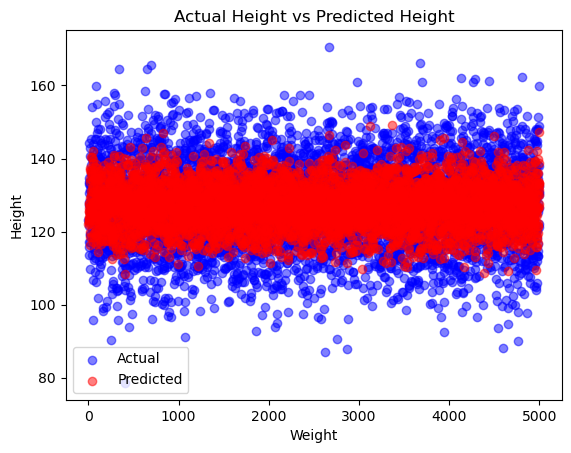

In [25]:
import matplotlib.pyplot as plt
_, ax = plt.subplots()
ax.scatter(x = range(0, y_test.size), y=y_test, c = 'blue', label = 'Actual',  
           alpha = 0.5)
ax.scatter(x = range(0, y_predicted.size), y=y_predicted, c = 'red',  
           label = 'Predicted', alpha = 0.5)
plt.title('Actual Height vs Predicted Height')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend()
plt.show()